In [ ]:
!pip install spiketools

In [2]:
import numpy as np
import re

In [3]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
%cd drive/MyDrive/deepLGitHub

In [ ]:
import os
os.getcwd()

In [6]:
SAVE_FIG_PATH = './Notebooks/Analysis/'
PRED_COLOR = 'm'
INPUT_COLOR = 'y'
MODEL_COLORS = 'm'

In [7]:
# get paths to all results csvs
RESULTS_PARENT_PATH = 'saved_model'
os.chdir(RESULTS_PARENT_PATH)
RESULTS_FOLDERS = os.listdir()
RESULTS_PATHS = []
for results_folder in RESULTS_FOLDERS:
    for result_path in os.listdir(results_folder):
        if ('Acc' in result_path):
            RESULTS_PATHS.append(results_folder + '/' + result_path + '/eval.csv')


In [8]:
RESULTS_PATHS

['Mix_T1_3T_T2_15T/230401_Acc_ResCUNet_AFT_ResCUNet/eval.csv',
 'Mix_T1_3T_T2_15T/230401_Acc_ResCUNet_AFT/eval.csv',
 'Mix_T1_3T_T2_15T/230401_Acc_AFT_ResCUNet/eval.csv',
 'Mix_T1_3T_T2_15T/230401_Acc_ResCUNet_i2i/eval.csv',
 'T2_15T/230401_Acc_ResCUNet_AFT/eval.csv',
 'T2_15T/230401_Acc_ResCUNet_AFT_ResCUNet/eval.csv',
 'T2_15T/230401_Acc_AFT_ResCUNet/eval.csv',
 'T2_15T/230401_Acc_ResCUNet_i2i/eval.csv',
 'T1_3T/230401_Acc_ResCUNet_AFT/eval.csv',
 'T1_3T/230401_Acc_ResCUNet_AFT_ResCUNet/eval.csv',
 'T1_3T/230401_Acc_ResCUNet_i2i/eval.csv',
 'T1_3T/230401_Acc_AFT_ResCUNet/eval.csv']

I = AFT CUNet <br>
K = CUNet AFT <br>
KI = CUNet AFT CUNet <br>

# Averages and standard deviations

In [ ]:
current_result_path = RESULTS_PATHS[3]

In [ ]:
current_result = pd.read_csv(current_result_path, delimiter=',')
current_result.head()

,Input,Input.1,Input.2,Prediction,Prediction.1,Prediction.2
0,SSIM,PSNR,NRMSE,SSIM,PSNR,NRMSE
1,1.0,inf,0.0,0.9755815859783199,40.34227811188597,0.06426802734552758
2,1.0,inf,0.0,0.9787045674043408,37.87973705717751,0.09154429739169492
3,1.0,inf,0.0,0.9830641281924473,42.59832267774627,0.059201387095809514
4,1.0,inf,0.0,0.9836542288161317,42.26248077623913,0.06677662000509278


In [ ]:
# fix column names and data type
current_result.columns = ['Input_SSIM', 'Input_PSNR', 'Input_NRMSE', 'Prediction_SSIM', 'Prediction_PSNR', 'Prediction_NRMSE']
current_result = current_result.drop(index=0, inplace=False).astype(float, copy=False)
current_result.head()

,Input_SSIM,Input_PSNR,Input_NRMSE,Prediction_SSIM,Prediction_PSNR,Prediction_NRMSE
1,1.0,inf,0.0,0.975582,40.342278,0.064268
2,1.0,inf,0.0,0.978705,37.879737,0.091544
3,1.0,inf,0.0,0.983064,42.598323,0.059201
4,1.0,inf,0.0,0.983654,42.262481,0.066777
5,1.0,inf,0.0,0.978084,42.153738,0.067765


In [ ]:
# get index of uncorrupted
original_idx = current_result.iloc[:, 0].values == 1
print('Uncorrupted: {} files'.format(sum(original_idx)))

Uncorrupted: 162 files


## Organize/save data

### Pre allocate/organize

In [9]:
from spiketools.plts.data import plot_text, plot_hist, plot_bar
from spiketools.plts.annotate import add_vshades, color_pvalue
from spiketools.plts.utils import make_grid, get_grid_subplot, save_figure

In [10]:
# pre-organize dictionary for data
results_original = {}
results_corrupted = {}
results_corrupted_pvals = {}
results_corrupted_tvals = {}
plot_corrupted = {}

columns_of_interest = ['Prediction_SSIM', 'Prediction_PSNR', 'Prediction_NRMSE']

all_columns = ['Input_SSIM', 'Input_PSNR', 'Input_NRMSE', 'Prediction_SSIM', 'Prediction_PSNR', 'Prediction_NRMSE']

for current_result_path in RESULTS_PATHS[::4]:
    dataset = re.sub('_', ' ', re.split(r'/', current_result_path)[0])
    # original data, only predictions
    results_original[dataset] = {re.sub('_', ' ', column): [] for column in columns_of_interest}
    # corrupted data, need to save input info too
    results_corrupted[dataset] = {re.sub('_', ' ', column): [] for column in all_columns}
    # corrupted data metrics for plotting
    plot_corrupted[dataset] = {re.sub('_', ' ', column): [] for column in all_columns}

    # corrupted pvals between input and output
    results_corrupted_pvals[dataset] = {re.sub('Prediction_', '', column): [] for column in columns_of_interest}
    results_corrupted_tvals[dataset] = {re.sub('Prediction_', '', column): [] for column in columns_of_interest}

# save row orders to make data frames
row_indices = []
for current_result_path in RESULTS_PATHS[:4]:
    model = re.sub('_', ' ', re.split('_', re.split(r'/', current_result_path)[1], maxsplit=2)[-1])
    row_indices.append(model)

In [11]:
n_metrics = len(results_original)

In [12]:
n_models = len(row_indices)

### Save all average measures +- standard deviations, corrupted p-vals in dictionaries

In [13]:
from scipy.stats import ttest_rel, ttest_ind

In [15]:
for current_result_path in RESULTS_PATHS:
    # dataset and model status
    dataset = re.sub('_', ' ', re.split(r'/', current_result_path)[0])
    model = re.sub('_', ' ', re.split('_', re.split(r'/', current_result_path)[1], maxsplit=2)[-1])
    if 'eval.csv' in os.listdir(current_result_path[:-9]):
        print('Processing {} dataset - {} model'.format(dataset, model))
        # organize data
        current_result = pd.read_csv(current_result_path, delimiter=',')
        current_result.columns = all_columns
        current_result = current_result.drop(index=0, inplace=False).astype(float, copy=False)
        # get index of uncorrupted
        original_idx = current_result.iloc[:, 0].values == 1
        print('Original files: {}'.format(sum(original_idx)))
        print('Corrupted files: {}\n'.format(sum(~original_idx)))

        for column in columns_of_interest:
            # for original data, get current columns' average and standard deviation for output only
            results_original[dataset][re.sub('_', ' ', column)].append(np.mean(current_result[column].values[original_idx]))

            # for corrupted data, get current columns' average and standard deviation for output and input
            results_corrupted[dataset][re.sub('_', ' ', column)].append(str(np.mean(current_result[column].values[~original_idx])) + ' +- ' +
                                                                      str(np.std(current_result[column].values[~original_idx])))
            results_corrupted[dataset][re.sub('Prediction_', 'Input ', column)].append(str(np.mean(current_result[re.sub('Prediction', 'Input', column)].
                                                                                                        values[~original_idx])) +
                                                                                            ' +- ' +
                                                                                            str(np.std(current_result[re.sub('Prediction', 'Input', column)].
                                                                                                        values[~original_idx])))
            # for corrupted data plotting, save all raw vals
            plot_corrupted[dataset][re.sub('_', ' ', column)].append(current_result[column].values[~original_idx])
            plot_corrupted[dataset][re.sub('Prediction_', 'Input ', column)].append(current_result[re.sub('Prediction', 'Input', column)].values[~original_idx])

            # paired ttest corrupted data compare input and predicted
            temp = ttest_rel(current_result[column].values[~original_idx], 
                             current_result[re.sub('Prediction', 'Input', column)].values[~original_idx])
            results_corrupted_pvals[dataset][re.sub('Prediction_', '', column)].append(temp[1])
            results_corrupted_tvals[dataset][re.sub('Prediction_', '', column)].append(temp[0])

    else:
        print('No {} dataset - {} model file \n'.format(dataset, model))

        for column in columns_of_interest:
            # for original data, get current columns' average and standard deviation for output only
            results_original[dataset][re.sub('_', ' ', column)].append(np.nan)

            # for corrupted data, get current columns' average and standard deviation for output and input
            results_corrupted[dataset][re.sub('_', ' ', column)].append(str(np.nan) + ' +- ' + str(np.nan))
            results_corrupted[dataset][re.sub('Prediction_', 'Input ', column)].append(str(np.nan) + ' +- ' + str(np.nan))
            # corrupted data compare input and predicted
            results_corrupted_pvals[dataset][re.sub('Prediction_', '', column)].append(np.nan)
            results_corrupted_tvals[dataset][re.sub('Prediction_', '', column)].append(np.nan)


Processing Mix T1 3T T2 15T dataset - ResCUNet AFT ResCUNet model
Original files: 162
Corrupted files: 162

Processing Mix T1 3T T2 15T dataset - ResCUNet AFT model
Original files: 162
Corrupted files: 162

Processing Mix T1 3T T2 15T dataset - AFT ResCUNet model
Original files: 162
Corrupted files: 162

Processing Mix T1 3T T2 15T dataset - ResCUNet i2i model
Original files: 162
Corrupted files: 162

Processing T2 15T dataset - ResCUNet AFT model
Original files: 139
Corrupted files: 139

Processing T2 15T dataset - ResCUNet AFT ResCUNet model
Original files: 139
Corrupted files: 139

Processing T2 15T dataset - AFT ResCUNet model
Original files: 139
Corrupted files: 139

Processing T2 15T dataset - ResCUNet i2i model
Original files: 139
Corrupted files: 139

Processing T1 3T dataset - ResCUNet AFT model
Original files: 23
Corrupted files: 23

Processing T1 3T dataset - ResCUNet AFT ResCUNet model
Original files: 23
Corrupted files: 23

Processing T1 3T dataset - ResCUNet i2i model
Ori

#Plot and stats

## Corrupted

- Histograms for measures between input and output of corrupted data per model (per dataset?)
- T-test input vs output for corrupted


Plotting Mix T1 3T T2 15T dataset
	model - ResCUNet AFT ResCUNet metric SSIM
	model - ResCUNet AFT ResCUNet metric PSNR
	model - ResCUNet AFT ResCUNet metric NRMSE
	model - ResCUNet AFT metric SSIM
	model - ResCUNet AFT metric PSNR
	model - ResCUNet AFT metric NRMSE
	model - AFT ResCUNet metric SSIM
	model - AFT ResCUNet metric PSNR
	model - AFT ResCUNet metric NRMSE
	model - ResCUNet i2i metric SSIM
	model - ResCUNet i2i metric PSNR
	model - ResCUNet i2i metric NRMSE

Plotting T2 15T dataset
	model - ResCUNet AFT ResCUNet metric SSIM
	model - ResCUNet AFT ResCUNet metric PSNR
	model - ResCUNet AFT ResCUNet metric NRMSE
	model - ResCUNet AFT metric SSIM
	model - ResCUNet AFT metric PSNR
	model - ResCUNet AFT metric NRMSE
	model - AFT ResCUNet metric SSIM
	model - AFT ResCUNet metric PSNR
	model - AFT ResCUNet metric NRMSE
	model - ResCUNet i2i metric SSIM
	model - ResCUNet i2i metric PSNR
	model - ResCUNet i2i metric NRMSE

Plotting T1 3T dataset
	model - ResCUNet AFT ResCUNet metric 

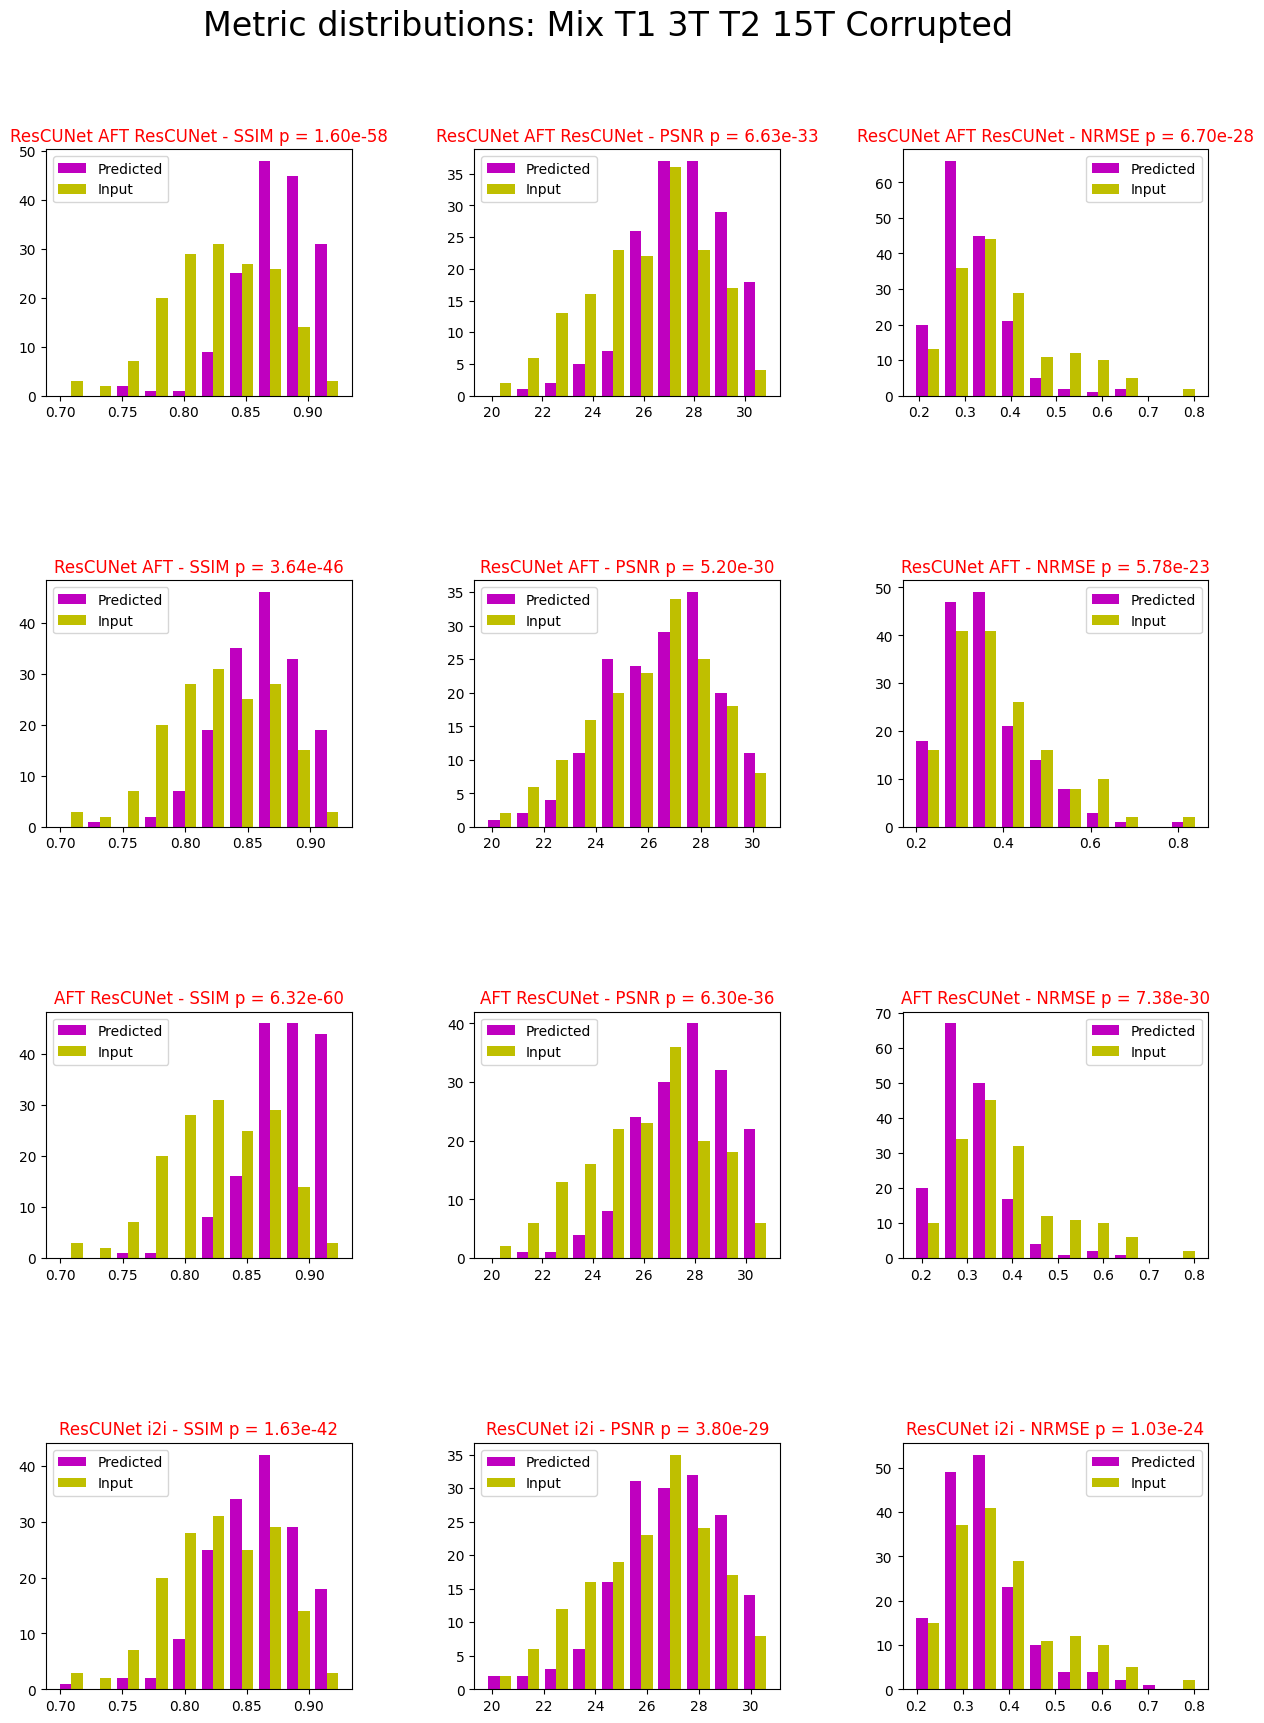

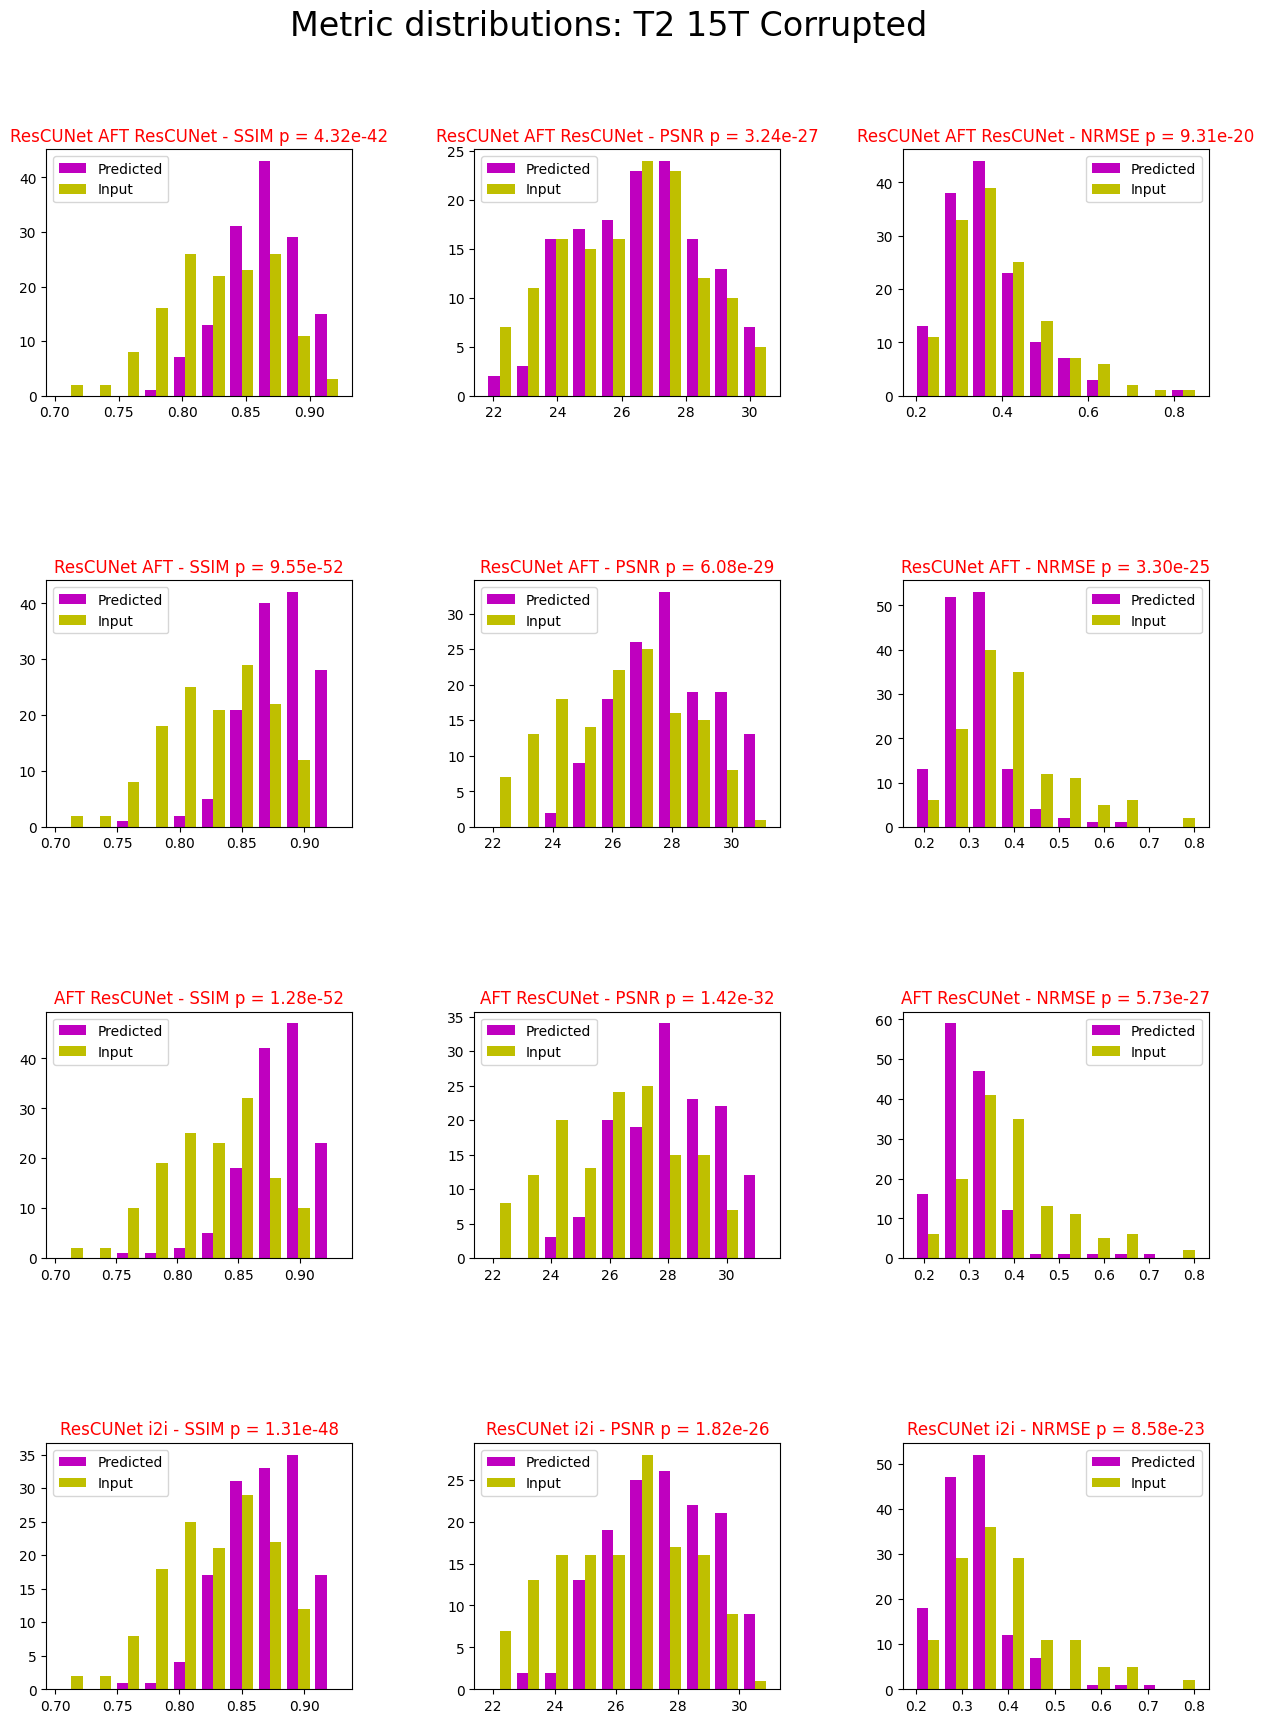

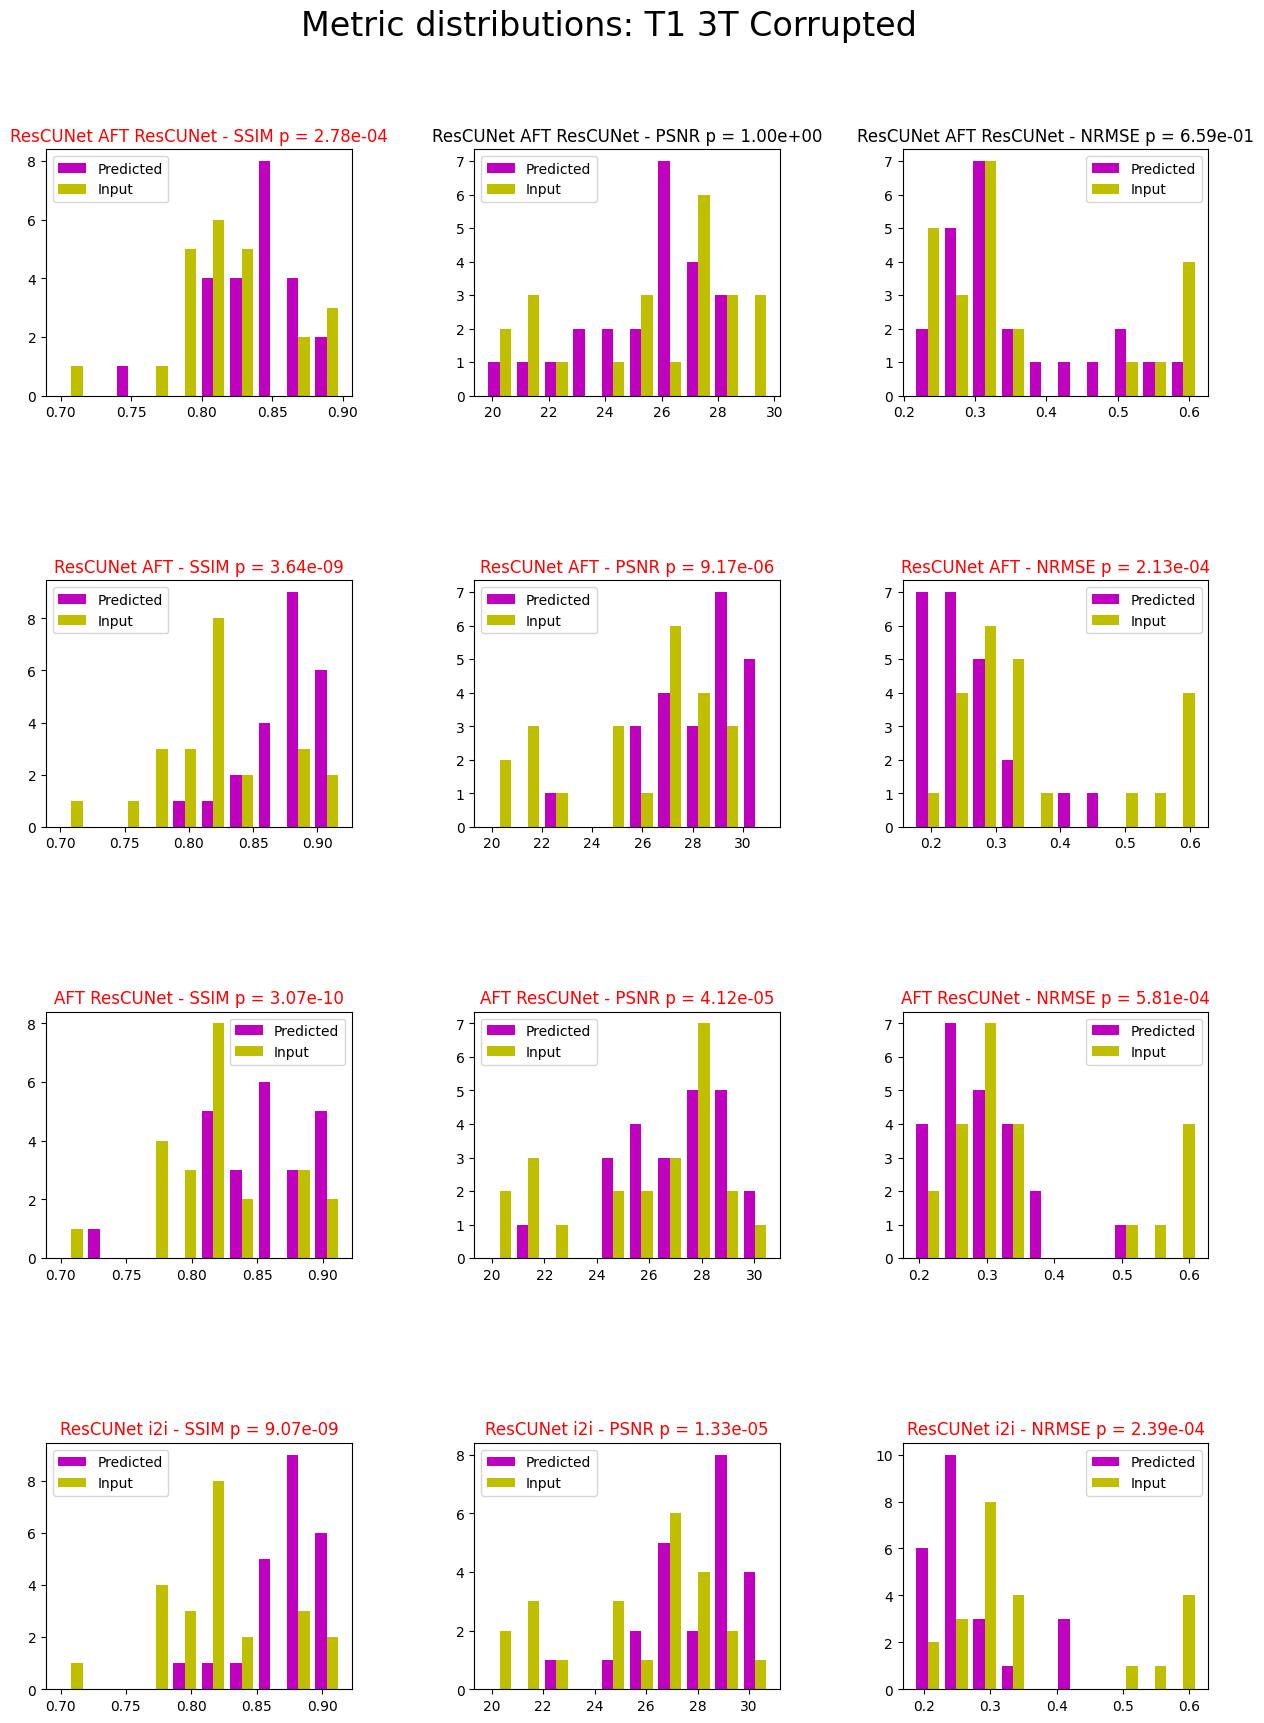

In [19]:
for current_dataset_path in RESULTS_PATHS[::4]:
    dataset = re.sub('_', ' ', re.split(r'/', current_dataset_path)[0])
    print('\nPlotting {} dataset'.format(dataset))

    grid = make_grid(n_models, n_metrics, wspace=0.4, hspace=0.75, figsize=(15, 20),
                    title='Metric distributions: {} Corrupted'.format(dataset))
    # print('Currently at: {}'.format(current_result_path[:-9]))
    # dataset and model status
    for model_idx, model in enumerate(row_indices):
        for metric_idx, column in enumerate(columns_of_interest):
            metric = re.sub('Prediction_', '', column)
            print('\tmodel - {} metric {}'.format(model, metric))

            plot_hist([plot_corrupted[dataset]['Prediction '+metric][model_idx], 
                       plot_corrupted[dataset]['Input '+metric][model_idx]],
                      color=[PRED_COLOR, INPUT_COLOR], legend=['Predicted', 'Input'],
                      title_color=color_pvalue(results_corrupted_pvals[dataset][metric][model_idx]),
                      title='{} - {} p = {:.2e}'.format(model, metric, results_corrupted_pvals[dataset][metric][model_idx]),
                      ax=get_grid_subplot(grid, model_idx, metric_idx))

    save_figure('plots_'+re.sub(' ', '_', dataset), close=False)
    save_figure('plots_'+re.sub(' ', '_', dataset)+'.pdf', close=False)

# Compare datasets

* t-test between (input - output) of each metric for each model between datasets

In [ ]:
# for corrupted data plotting, save all raw vals
plot_corrupted[dataset][re.sub('_', ' ', column)].append(current_result[column].values[~original_idx])
plot_corrupted[dataset][re.sub('Prediction_', 'Input ', column)].append(current_result[re.sub('Prediction', 'Input', column)].values[~original_idx])

# paired ttest corrupted data compare input and predicted
temp = ttest_rel(current_result[column].values[~original_idx], 
                  current_result[re.sub('Prediction', 'Input', column)].values[~original_idx])

In [ ]:
print('\nPlotting comparison {} dataset'.format(dataset))

    grid = make_grid(n_models, n_metrics, wspace=0.4, hspace=0.75, figsize=(15, 20),
                    title='Metric distributions: {} Corrupted'.format(dataset))
    # print('Currently at: {}'.format(current_result_path[:-9]))
    # dataset and model status
    for model_idx, model in enumerate(row_indices):
        for metric_idx, column in enumerate(columns_of_interest):
            metric = re.sub('Prediction_', '', column)
            print('\tmodel - {} metric'.format(model, metric))

            plot_hist([plot_corrupted[dataset]['Prediction '+metric][model_idx], 
                       plot_corrupted[dataset]['Input '+metric][model_idx]],
                      color=[PRED_COLOR, INPUT_COLOR], legend=['Predicted', 'Input'],
                      title_color=color_pvalue(results_corrupted_pvals[dataset][metric][model_idx]),
                      title='{} - {} p = {:.2e}'.format(model, metric, results_corrupted_pvals[dataset][metric][model_idx]),
                      ax=get_grid_subplot(grid, model_idx, metric_idx))

    save_figure('plots_'+re.sub(' ', '_', dataset), close=False)
    save_figure('plots_'+re.sub(' ', '_', dataset)+'.pdf', close=False)

[array([0.88719299, 0.87710451, 0.8607561 , 0.85440792, 0.81233144,
        0.85841413, 0.81287763, 0.80768126, 0.86542104, 0.84050969,
        0.85052483, 0.82542716, 0.85042062, 0.87410808, 0.82684362,
        0.83976568, 0.83185542, 0.80509334, 0.88296686, 0.74486466,
        0.84387014, 0.85445107, 0.82819543]),
 array([0.88650654, 0.89612185, 0.81657192, 0.83512819, 0.7808108 ,
        0.8216661 , 0.7626372 , 0.78034945, 0.83548405, 0.80815659,
        0.81606717, 0.82206799, 0.80054439, 0.87586921, 0.78134791,
        0.87787559, 0.79039649, 0.79785547, 0.89874863, 0.69734737,
        0.81925366, 0.81550827, 0.81540062])]

In [ ]:
plot_hist([plot_corrupted[dataset]['Prediction '+metric][model_idx], 
                       plot_corrupted[dataset]['Input '+metric][model_idx]],
                      color=[PRED_COLOR, INPUT_COLOR], legend=['Predicted', 'Input'],
                      title_color=color_pvalue(results_corrupted_pvals[dataset][re.split('_', column)[-1]][model_idx]),
                      title='{} - {} p = {:.2e}'.format(model, metric),
                      ax=get_grid_subplot(grid, model_idx, metric_idx))

In [ ]:
[plot_corrupted[dataset]['Prediction '+metric], 
                       plot_corrupted[dataset]['Input '+metric]]

[[array([0.88719299, 0.87710451, 0.8607561 , 0.85440792, 0.81233144,
         0.85841413, 0.81287763, 0.80768126, 0.86542104, 0.84050969,
         0.85052483, 0.82542716, 0.85042062, 0.87410808, 0.82684362,
         0.83976568, 0.83185542, 0.80509334, 0.88296686, 0.74486466,
         0.84387014, 0.85445107, 0.82819543]),
  array([0.91819345, 0.90384247, 0.90364326, 0.88147128, 0.84680857,
         0.89890974, 0.86752975, 0.86892487, 0.89666902, 0.87702748,
         0.88902664, 0.85058321, 0.88295527, 0.89560463, 0.8676062 ,
         0.88340384, 0.88489083, 0.82888972, 0.91529979, 0.792084  ,
         0.88902538, 0.88906412, 0.86496505]),
  array([0.9076204 , 0.90613177, 0.8741015 , 0.86151834, 0.80704742,
         0.87492506, 0.81744925, 0.82524322, 0.87651494, 0.84454744,
         0.86391452, 0.83902708, 0.85294586, 0.89275122, 0.81025361,
         0.89410083, 0.83664268, 0.81044755, 0.91393876, 0.73384921,
         0.86075928, 0.86663318, 0.85445385]),
  array([0.91430111, 0.90513692

In [ ]:
row_indices

['ResCUNet AFT ResCUNet', 'ResCUNet AFT', 'AFT ResCUNet', 'ResCUNet i2i']

In [ ]:
np.where(np.array(row_indices) == model)[0][0]

2

In [ ]:
results_corrupted_pvals[dataset][re.split('_', column)[-1]]

[0.6588506795048296,
 0.0002126480279608993,
 0.0005806441120702753,
 0.000238798098933373]

In [ ]:
for column in columns_of_interest:
    current_result[column].values[~original_idx], current_result[re.sub('Prediction', 'Input', column)].values[~original_idx]

In [ ]:
title_color=color_pvalue(results_corrupted_pvals[dataset]['Input vs Predicted ' + re.split('_', '', column)[-1]])

In [ ]:
grid = make_grid(n_models, n_metrics, wspace=0.4, hspace=0.75, figsize=(15, 20),
                 title='Metric distributions: {}'.format('Corrupted'))
for row_index in row_indices:
# plot_text(create_nan_result_str('Freeze trace window avg (t-test)'),
#                                               ax=get_grid_subplot(grid, 12, 2))
    plot_hist([current_result[column].values[~original_idx], current_result[re.sub('Prediction', 'Input', column)].values[~original_idx]],
              color=[PRED_COLOR, INPUT_COLOR], legend=['prediction', 'input'], 
              title=re.split(' ', dataset)[0] + ' - ' + re.split('_', column)[-1])
plot_hist(pre_start_spike_values+post_start_spike_values, 
                                      bins=PLOT['spike_count_bins'],
                                      title='Spike Value Counts Pre and Post Freezing', 
                                      color=(len(pre_start_spike_values)*[PLOT['pre_color']]) + (len(post_start_spike_values)*[PLOT['post_color']]),
                                      ax=get_grid_subplot(grid, slice(4, 6), slice(0, 2)))
add_vshades([freeze_pre_time_window[0], freeze_pre_time_window[1], 0, 2.5], alpha=0.1, color=PLOT['pre_color'],
                                          ax=get_grid_subplot(grid, slice(10, 12), slice(0, 2)))


                        # Save out the report
                        save_figure(name + '.pdf', reports_folder, close=True)